# Phase 0: Blind Community Detection on Polymarket

This notebook proves the data pipeline works on a single well-defined slice of Polymarket markets,
then runs BlindCD (covariance → top-K eigenvectors → K-means) and checks whether the resulting
clusters correspond to anything semantically meaningful.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import asyncio
import json
from datetime import datetime, timezone, timedelta

import numpy as np
import polars as pl

from src.api import get_events, get_markets_for_event, get_markets_by_event_id, fetch_all_price_histories
from src.pipeline import build_panel, compute_log_odds_returns, run_blindcd
from src.plots import plot_eigenvalue_spectrum, plot_covariance_heatmap, plot_embedding, print_clusters

%matplotlib inline

## 1. Explore available events

Pull events from the Gamma API and find one with 8-20 sub-markets, good liquidity, and enough price history.

In [2]:
# Fetch a broad set of events (multiple pages to get variety)
all_events = []
for offset in range(0, 500, 100):
    batch = get_events(limit=100, offset=offset)
    if not batch:
        break
    all_events.extend(batch)
    print(f"  Fetched {len(batch)} events at offset {offset} (total: {len(all_events)})")

print(f"\nTotal events fetched: {len(all_events)}")

  Fetched 100 events at offset 0 (total: 100)


  Fetched 100 events at offset 100 (total: 200)


  Fetched 100 events at offset 200 (total: 300)


  Fetched 100 events at offset 300 (total: 400)


  Fetched 100 events at offset 400 (total: 500)

Total events fetched: 500


In [3]:
# Score events: prefer 10-25 markets with individually active sub-markets
def score_event(event):
    markets = event.get("markets", [])
    if not isinstance(markets, list):
        return -1
    n = len(markets)
    total_vol = float(event.get("volume", 0) or 0)

    # Must have enough sub-markets
    if n < 8:
        return -1

    # Count markets with meaningful individual volume (>$1k each)
    active_markets = sum(1 for m in markets if float(m.get("volume", 0) or 0) > 1000)
    if active_markets < 6:
        return -1

    # Prefer 10-25 range (sweet spot for clustering)
    size_score = 1.0 if 10 <= n <= 25 else 0.8 if 8 <= n <= 30 else 0.3
    # Active market ratio — penalize events where most sub-markets are dead
    active_ratio = active_markets / n
    vol_score = min(total_vol / 1_000_000, 10)

    return size_score * active_ratio * vol_score

scored = [(score_event(e), e) for e in all_events]
scored = [(s, e) for s, e in scored if s > 0]
scored.sort(key=lambda x: -x[0])

print(f"Events with 8+ active markets: {len(scored)}\n")
print("Top 15 candidates:")
print("-" * 100)
for score, e in scored[:15]:
    markets = e.get("markets", [])
    n = len(markets) if isinstance(markets, list) else 0
    active = sum(1 for m in markets if float(m.get("volume", 0) or 0) > 1000)
    vol = float(e.get("volume", 0) or 0)
    print(f"  score={score:>6.2f}  mkts={n:2d}  active={active:2d}  vol=${vol:>12,.0f}  {e.get('title', '?')[:50]}")

Events with 8+ active markets: 133

Top 15 candidates:
----------------------------------------------------------------------------------------------------
  score= 10.00  mkts=13  active=13  vol=$  20,870,084  How many Fed rate cuts in 2026?
  score= 10.00  mkts=17  active=17  vol=$  17,520,840  Which companies will be acquired before 2027?
  score=  8.00  mkts= 9  active= 9  vol=$  21,387,169  What will happen before GTA VI?
  score=  8.00  mkts= 8  active= 8  vol=$  18,732,769  MegaETH market cap (FDV) one day after launch? 
  score=  6.88  mkts=16  active=11  vol=$  15,279,204  NBA Eastern Conference Champion 
  score=  6.88  mkts=16  active=11  vol=$  18,906,232  NBA Western Conference Champion 
  score=  6.25  mkts=24  active=15  vol=$  16,173,971  French Ligue 1: Winner 
  score=  6.11  mkts=16  active=15  vol=$   6,512,546  How many different countries will Israel strike in
  score=  6.00  mkts=25  active=15  vol=$ 319,360,408  English Premier League Winner 
  score=  5.93  mkt

In [4]:
# Select the top-scoring event
chosen_event = scored[0][1]
print(f"Chosen event: {chosen_event['title']}")
print(f"  ID: {chosen_event['id']}")
print(f"  Slug: {chosen_event.get('slug', 'N/A')}")
print(f"  Volume: ${float(chosen_event.get('volume', 0)):,.0f}")

# Extract markets from the event
event_markets = chosen_event.get("markets", [])
print(f"  Markets in event: {len(event_markets)}")
print()

for i, m in enumerate(event_markets):
    q = m.get("question", m.get("title", "?"))
    vol = float(m.get("volume", 0) or 0)
    print(f"  [{i}] {q[:70]}  vol=${vol:>10,.0f}")

Chosen event: How many Fed rate cuts in 2026?
  ID: 51456
  Slug: how-many-fed-rate-cuts-in-2026
  Volume: $20,870,084
  Markets in event: 13

  [0] Will no Fed rate cuts happen in 2026?  vol=$ 3,470,674
  [1] Will 1 Fed rate cut happen in 2026?  vol=$ 1,099,007
  [2] Will 2 Fed rate cuts happen in 2026?  vol=$ 1,062,080
  [3] Will 3 Fed rate cuts happen in 2026?  vol=$   976,874
  [4] Will 4 Fed rate cuts happen in 2026?  vol=$ 1,026,756
  [5] Will 5 Fed rate cuts happen in 2026?  vol=$ 1,160,098
  [6] Will 6 Fed rate cuts happen in 2026?  vol=$ 2,189,127
  [7] Will 7 Fed rate cuts happen in 2026?  vol=$   977,712
  [8] Will 8 Fed rate cuts happen in 2026?  vol=$ 1,319,606
  [9] Will 9 Fed rate cuts happen in 2026?  vol=$ 1,420,280
  [10] Will 10 Fed rate cuts happen in 2026?  vol=$ 1,884,345
  [11] Will 11 Fed rate cuts happen in 2026?  vol=$ 2,373,449
  [12] Will 12 or more Fed rate cuts happen in 2026?  vol=$ 1,910,516


## 2. Pull price history

Get Yes-side token IDs for each market and fetch hourly price data for the last 14 days.

In [5]:
# Extract Yes-side token IDs and build metadata lookup
token_ids = []
token_meta = {}  # token_id -> market metadata

for m in event_markets:
    # clobTokenIds is typically "[yes_id, no_id]" as a JSON string or list
    clob = m.get("clobTokenIds")
    if isinstance(clob, str):
        clob = json.loads(clob)
    if clob and len(clob) >= 1:
        yes_id = clob[0]
        token_ids.append(yes_id)
        token_meta[yes_id] = {
            "question": m.get("question", m.get("title", "?")),
            "token_id": yes_id,
            "volume": float(m.get("volume", 0) or 0),
        }

print(f"Yes-side tokens: {len(token_ids)}")
for tid in token_ids:
    print(f"  {tid[:12]}...  {token_meta[tid]['question'][:60]}")

Yes-side tokens: 13
  124036029200...  Will no Fed rate cuts happen in 2026?
  113379839734...  Will 1 Fed rate cut happen in 2026?
  725355440178...  Will 2 Fed rate cuts happen in 2026?
  958357050624...  Will 3 Fed rate cuts happen in 2026?
  731974411272...  Will 4 Fed rate cuts happen in 2026?
  292132524466...  Will 5 Fed rate cuts happen in 2026?
  775313404236...  Will 6 Fed rate cuts happen in 2026?
  832250629008...  Will 7 Fed rate cuts happen in 2026?
  792249498559...  Will 8 Fed rate cuts happen in 2026?
  231260315774...  Will 9 Fed rate cuts happen in 2026?
  101699865858...  Will 10 Fed rate cuts happen in 2026?
  563453497437...  Will 11 Fed rate cuts happen in 2026?
  934823447073...  Will 12 or more Fed rate cuts happen in 2026?


In [6]:
# Time window: last 14 days
end_dt = datetime.now(timezone.utc)
start_dt = end_dt - timedelta(days=14)
start_ts = int(start_dt.timestamp())
end_ts = int(end_dt.timestamp())

print(f"Time window: {start_dt.date()} to {end_dt.date()}")
print(f"  start_ts={start_ts}, end_ts={end_ts}")
print(f"  Fetching {len(token_ids)} price histories (fidelity=60 min)...")

# Fetch all price histories (async with rate limiting)
price_data = await fetch_all_price_histories(
    token_ids, start_ts, end_ts, fidelity=60, max_concurrent=3
)

for tid, hist in price_data.items():
    n = len(hist.get("history", hist)) if isinstance(hist, dict) else len(hist)
    print(f"  {tid[:12]}...  {n} bars")

Time window: 2026-04-11 to 2026-04-25
  start_ts=1775945424, end_ts=1777155024
  Fetching 13 price histories (fidelity=60 min)...


  124036029200...  149 bars
  725355440178...  199 bars
  113379839734...  255 bars
  958357050624...  307 bars
  731974411272...  308 bars
  292132524466...  248 bars
  775313404236...  216 bars
  792249498559...  248 bars
  832250629008...  158 bars
  231260315774...  229 bars
  101699865858...  227 bars
  563453497437...  180 bars
  934823447073...  149 bars


In [7]:
# Assemble into long-format DataFrame
rows = []
for tid, hist in price_data.items():
    # Handle both {"history": [...]} and bare list responses
    points = hist.get("history", hist) if isinstance(hist, dict) else hist
    for pt in points:
        rows.append({
            "token_id": tid,
            "timestamp": datetime.fromtimestamp(int(pt["t"]), tz=timezone.utc),
            "price": float(pt["p"]),
        })

prices_long = pl.DataFrame(rows)
print(f"Long-format prices: {prices_long.shape}")
print(f"  Unique tokens: {prices_long['token_id'].n_unique()}")
print(f"  Date range: {prices_long['timestamp'].min()} → {prices_long['timestamp'].max()}")
print(prices_long.head())

# Save to parquet
import pathlib
processed_dir = pathlib.Path("..") / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
prices_long.write_parquet(processed_dir / "prices_long.parquet")
print(f"\nSaved to data/processed/prices_long.parquet")

Long-format prices: (2873, 3)
  Unique tokens: 13
  Date range: 2026-04-11 23:00:43+00:00 → 2026-04-25 22:10:05+00:00
shape: (5, 3)
┌─────────────────────────────────┬─────────────────────────┬────────┐
│ token_id                        ┆ timestamp               ┆ price  │
│ ---                             ┆ ---                     ┆ ---    │
│ str                             ┆ datetime[μs, UTC]       ┆ f64    │
╞═════════════════════════════════╪═════════════════════════╪════════╡
│ 124036029200392690775979173409… ┆ 2026-04-12 00:00:18 UTC ┆ 0.4015 │
│ 124036029200392690775979173409… ┆ 2026-04-12 16:00:13 UTC ┆ 0.403  │
│ 124036029200392690775979173409… ┆ 2026-04-13 04:00:55 UTC ┆ 0.4255 │
│ 124036029200392690775979173409… ┆ 2026-04-13 16:00:04 UTC ┆ 0.4185 │
│ 124036029200392690775979173409… ┆ 2026-04-13 22:00:01 UTC ┆ 0.412  │
└─────────────────────────────────┴─────────────────────────┴────────┘

Saved to data/processed/prices_long.parquet


## 3. Build the panel and compute log-odds returns

In [8]:
# Build clean wide panel
panel, dropped = build_panel(prices_long, fidelity_minutes=60)

token_cols = [c for c in panel.columns if c != "timestamp"]
print(f"Panel shape: {panel.shape}")
print(f"  Surviving markets: {len(token_cols)}")
print(f"  Time bars: {panel.height}")
print(f"  Date range: {panel['timestamp'].min()} → {panel['timestamp'].max()}")

if dropped:
    print(f"\n  Dropped markets ({len(dropped)}):")
    for d in dropped:
        label = token_meta.get(d['token_id'], {}).get('question', d['token_id'][:20])
        print(f"    - {label}: {d['reason']}")
else:
    print("  No markets dropped.")

Panel shape: (242, 9)
  Surviving markets: 8
  Time bars: 242
  Date range: 2026-04-15 21:00:43+00:00 → 2026-04-25 22:00:43+00:00

  Dropped markets (5):
    - Will no Fed rate cuts happen in 2026?: missing 100.0%
    - Will 2 Fed rate cuts happen in 2026?: missing 37.2%
    - Will 6 Fed rate cuts happen in 2026?: missing 100.0%
    - Will 7 Fed rate cuts happen in 2026?: missing 100.0%
    - Will 11 Fed rate cuts happen in 2026?: missing 37.2%


In [9]:
# Compute log-odds returns
returns = compute_log_odds_returns(panel)
ret_cols = [c for c in returns.columns if c != "timestamp"]

print(f"Returns shape: {returns.shape}")
print(f"\nPer-market summary stats:")
print(f"{'Market':<65} {'mean':>8} {'std':>8} {'nonzero':>8}")
print("-" * 95)
for c in ret_cols:
    col = returns[c]
    label = token_meta.get(c, {}).get('question', c[:20])[:60]
    mean_val = col.mean()
    std_val = col.std()
    nonzero = (col.abs() > 1e-10).sum()
    print(f"{label:<65} {mean_val:>8.4f} {std_val:>8.4f} {nonzero:>8}")

# Sanity check
assert returns.drop("timestamp").null_count().sum_horizontal().item() == 0, "NaNs in returns!"
print("\n✓ No NaNs in returns matrix.")

Returns shape: (241, 9)

Per-market summary stats:
Market                                                                mean      std  nonzero
-----------------------------------------------------------------------------------------------
Will 1 Fed rate cut happen in 2026?                                 0.0008   0.0101        2
Will 3 Fed rate cuts happen in 2026?                               -0.0015   0.0187        4
Will 4 Fed rate cuts happen in 2026?                                0.0014   0.0241       10
Will 5 Fed rate cuts happen in 2026?                                0.0003   0.0050        1
Will 8 Fed rate cuts happen in 2026?                                0.0000   0.0000        0
Will 9 Fed rate cuts happen in 2026?                                0.0000   0.0000        0
Will 10 Fed rate cuts happen in 2026?                               0.0000   0.0000        0
Will 12 or more Fed rate cuts happen in 2026?                       0.0005   0.0081        1

✓ No NaNs in re

## 4. Run BlindCD pipeline

In [10]:
K = 3  # Number of clusters — try 3 or 4

result = run_blindcd(returns, K=K)

print(f"Eigenvalue spectrum (top 10):")
for i, ev in enumerate(result["eigenvalues"][:10]):
    print(f"  λ_{i+1} = {ev:.6f}")

print(f"\nCluster assignments:")
for tid, label in zip(result["token_ids"], result["labels"]):
    q = token_meta.get(tid, {}).get("question", tid[:20])
    print(f"  Cluster {label}: {q[:70]}")

Eigenvalue spectrum (top 10):
  λ_1 = 0.000580
  λ_2 = 0.000344
  λ_3 = 0.000103
  λ_4 = 0.000066
  λ_5 = 0.000025
  λ_6 = 0.000000
  λ_7 = 0.000000
  λ_8 = 0.000000

Cluster assignments:
  Cluster 2: Will 1 Fed rate cut happen in 2026?
  Cluster 1: Will 3 Fed rate cuts happen in 2026?
  Cluster 0: Will 4 Fed rate cuts happen in 2026?
  Cluster 1: Will 5 Fed rate cuts happen in 2026?
  Cluster 1: Will 8 Fed rate cuts happen in 2026?
  Cluster 1: Will 9 Fed rate cuts happen in 2026?
  Cluster 1: Will 10 Fed rate cuts happen in 2026?
  Cluster 1: Will 12 or more Fed rate cuts happen in 2026?


## 5. Visualize results

In [11]:
# Short labels for plots
market_labels = [
    token_meta.get(tid, {}).get("question", tid[:15])[:30]
    for tid in result["token_ids"]
]

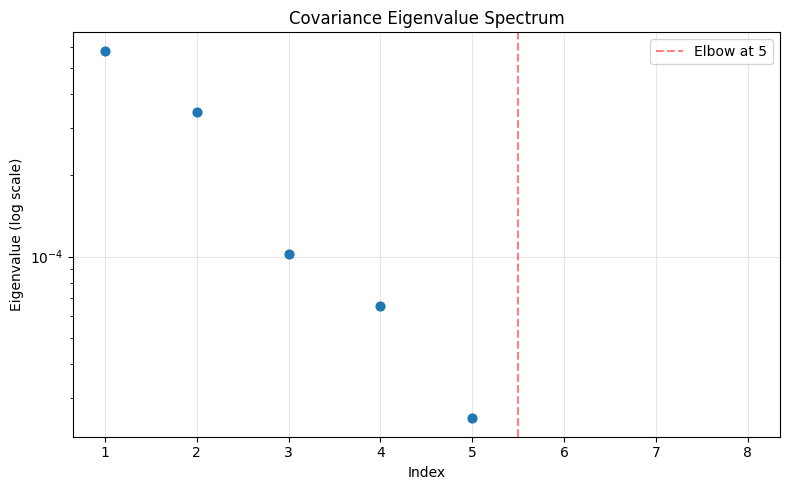

In [12]:
# Eigenvalue spectrum
plot_eigenvalue_spectrum(result["eigenvalues"]);

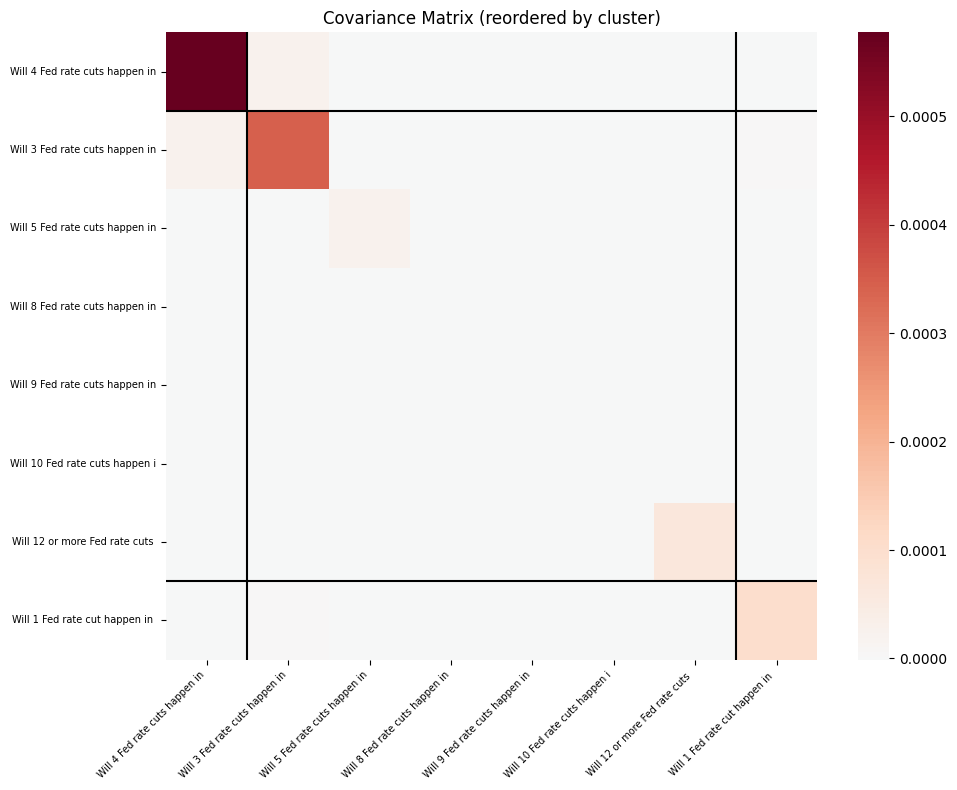

In [13]:
# Covariance heatmap (reordered by cluster)
plot_covariance_heatmap(result["cov_matrix"], market_labels, result["labels"]);

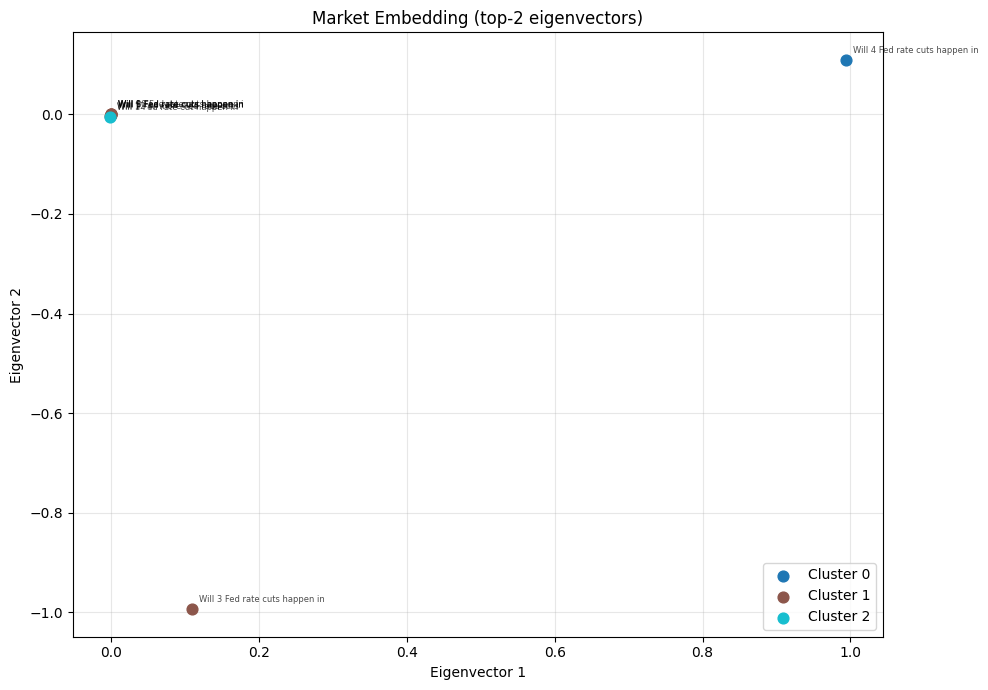

In [14]:
# Embedding scatter (first 2 eigenvectors)
plot_embedding(result["embedding"], market_labels, result["labels"]);

In [15]:
# Print clusters with full market titles
meta_list = [token_meta.get(tid, {"token_id": tid}) for tid in result["token_ids"]]
print_clusters(meta_list, result["labels"])


  CLUSTER 0 (1 markets)
  - Will 4 Fed rate cuts happen in 2026?

  CLUSTER 1 (6 markets)
  - Will 3 Fed rate cuts happen in 2026?
  - Will 5 Fed rate cuts happen in 2026?
  - Will 8 Fed rate cuts happen in 2026?
  - Will 9 Fed rate cuts happen in 2026?
  - Will 10 Fed rate cuts happen in 2026?
  - Will 12 or more Fed rate cuts happen in 2026?

  CLUSTER 2 (1 markets)
  - Will 1 Fed rate cut happen in 2026?


## 6. Try K=4 for comparison


  CLUSTER 0 (1 markets)
  - Will 4 Fed rate cuts happen in 2026?

  CLUSTER 1 (5 markets)
  - Will 3 Fed rate cuts happen in 2026?
  - Will 5 Fed rate cuts happen in 2026?
  - Will 8 Fed rate cuts happen in 2026?
  - Will 9 Fed rate cuts happen in 2026?
  - Will 10 Fed rate cuts happen in 2026?

  CLUSTER 2 (1 markets)
  - Will 1 Fed rate cut happen in 2026?

  CLUSTER 3 (1 markets)
  - Will 12 or more Fed rate cuts happen in 2026?


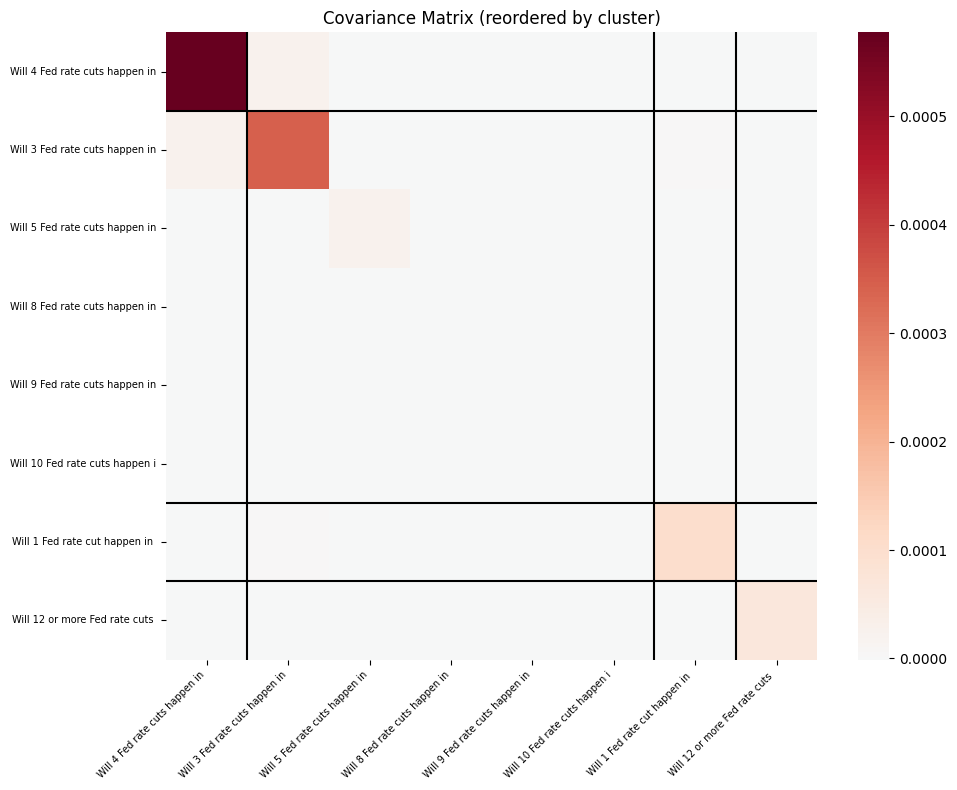

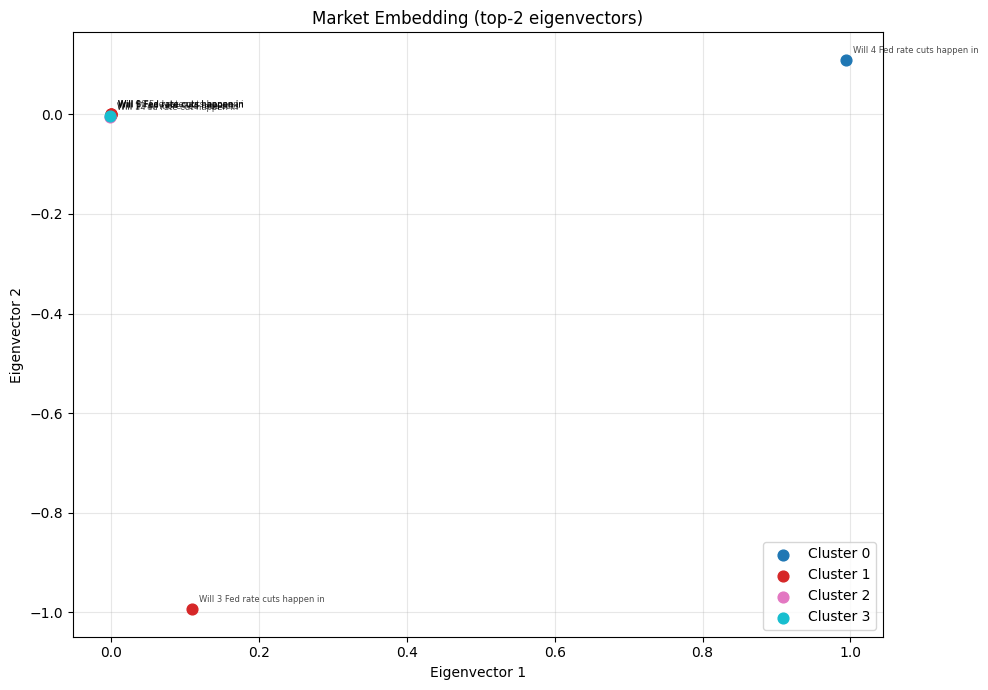

In [16]:
n_surviving = len([c for c in returns.columns if c != "timestamp"])
K4 = min(4, n_surviving - 1)
if K4 > K and n_surviving >= 6:
    result4 = run_blindcd(returns, K=K4)
    market_labels4 = [
        token_meta.get(tid, {}).get("question", tid[:15])[:30]
        for tid in result4["token_ids"]
    ]
    plot_covariance_heatmap(result4["cov_matrix"], market_labels4, result4["labels"]);
    plot_embedding(result4["embedding"], market_labels4, result4["labels"]);
    meta_list4 = [token_meta.get(tid, {"token_id": tid}) for tid in result4["token_ids"]]
    print_clusters(meta_list4, result4["labels"])
else:
    print(f"Skipping K={K4} (only {n_surviving} surviving markets, need at least 6)")

## 7. Sanity Check and Assessment

**Fill in after running the notebook:**

### Which event did we pick? How many markets, how many bars?
- Event: *(filled by output above)*
- Markets surviving panel cleanup: *(see panel shape above)*
- Time bars: *(see panel shape above)*

### Did the eigenvalue spectrum show a clear low-pass structure?
- Look at the eigenvalue spectrum plot above. A sharp drop after the top few eigenvalues
  indicates low-pass structure (energy concentrated in a few modes), which is the assumption
  BlindCD relies on.

### Do the recovered clusters correspond to anything semantically meaningful?
- Read the cluster printout above. Do markets within the same cluster share a common theme
  (same sport/team/region, correlated outcomes, similar odds profiles)?

### What surprised you?
- *(Fill in after inspecting results)*

### What's the next thing to try?
- Try different K values to see how clusters split/merge
- Try minute-level fidelity for more signal
- Expand to multiple events and cluster across events
- Compare against graphical lasso or other methods
- Auto-select K via eigengap heuristic